## load data

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv("D:\\forecasting\\data\\train.csv")
features = pd.read_csv("D:\\forecasting\\data\\features.csv")
stores = pd.read_csv("D:\\forecasting\\data\\stores.csv")

In [3]:
print(train.shape)

(421570, 5)


In [4]:
print(features.shape)

(8190, 12)


In [5]:
print(stores.shape)

(45, 3)


In [6]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [8]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [9]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [10]:
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [11]:
stores.isnull().sum()

Store    0
Type     0
Size     0
dtype: int64

## data merge


In [12]:
df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores,
    on="Store",
    how="left"
)

In [13]:
df.shape

(421570, 16)

In [14]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## missing values


In [15]:
df["CPI"] = df["CPI"].fillna(df["CPI"].median())

df["Unemployment"] = df["Unemployment"].fillna(
    df["Unemployment"].median()
)

In [16]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

## date-time conversion

In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

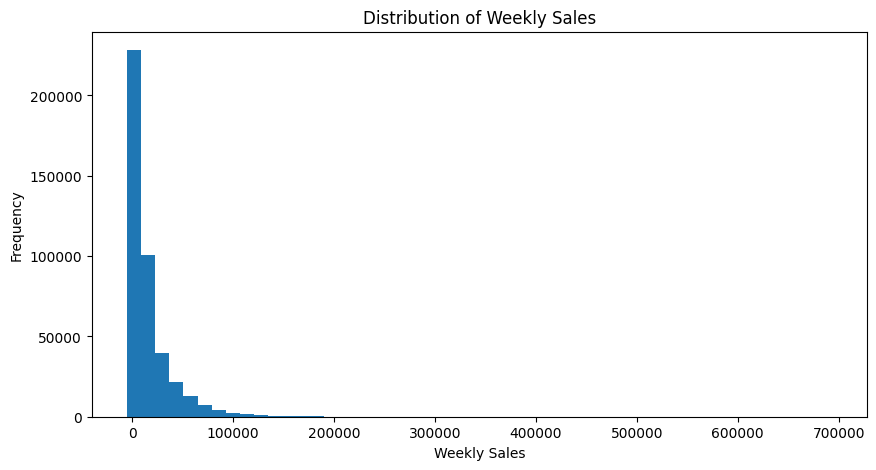

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["Weekly_Sales"],
    bins=50
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

# EDA

### Sales Trend

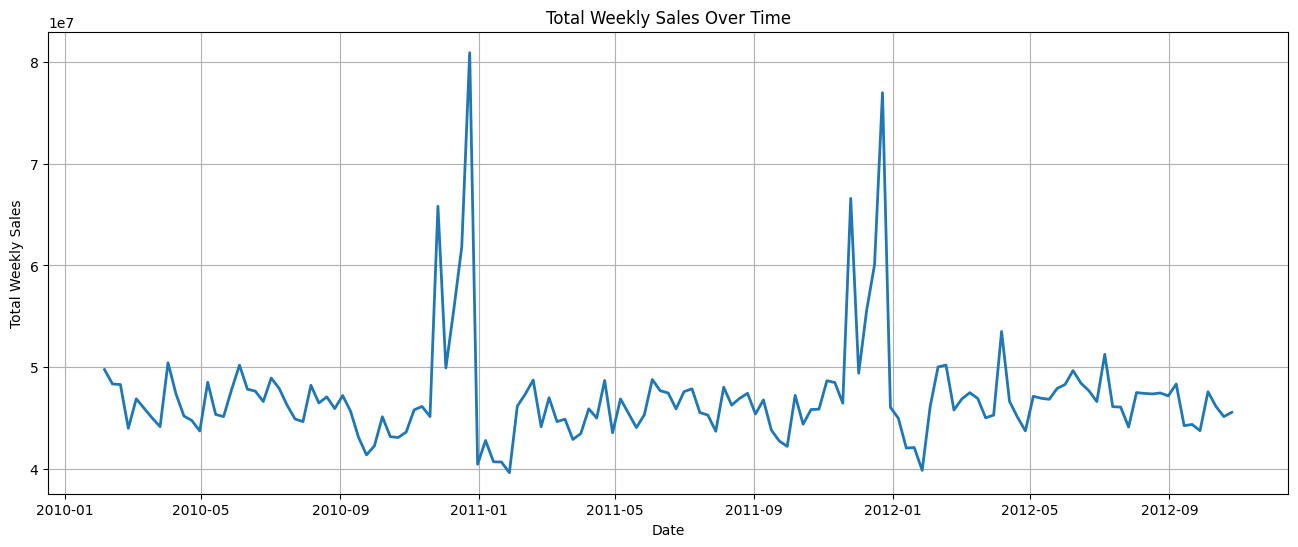

In [20]:
import matplotlib.pyplot as plt

sales_trend = (
    df.groupby("Date")["Weekly_Sales"]
      .sum()
)

plt.figure(figsize=(16,6))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    linewidth=2
)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.grid(True)

plt.show()

### MONTHLY SEASONALITY

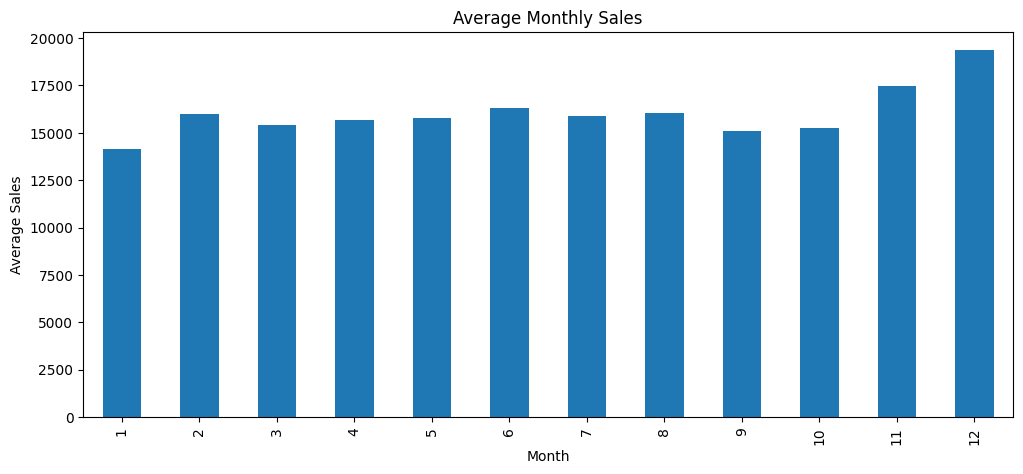

In [21]:
df["Month"] = df["Date"].dt.month

monthly_sales = (
    df.groupby("Month")["Weekly_Sales"]
      .mean()
)

plt.figure(figsize=(12,5))

monthly_sales.plot(kind="bar")

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

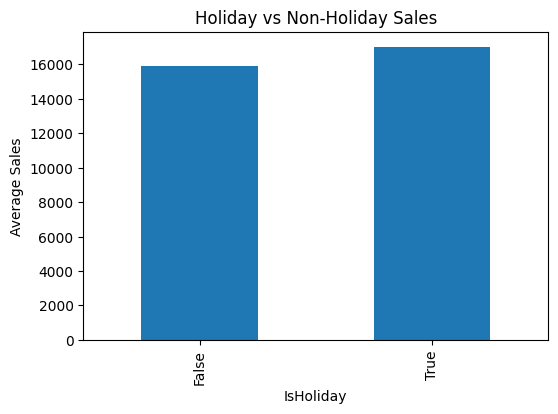

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


In [22]:
holiday_sales = (
    df.groupby("IsHoliday")["Weekly_Sales"]
      .mean()
)

holiday_sales.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("Average Sales")

plt.show()

print(holiday_sales)

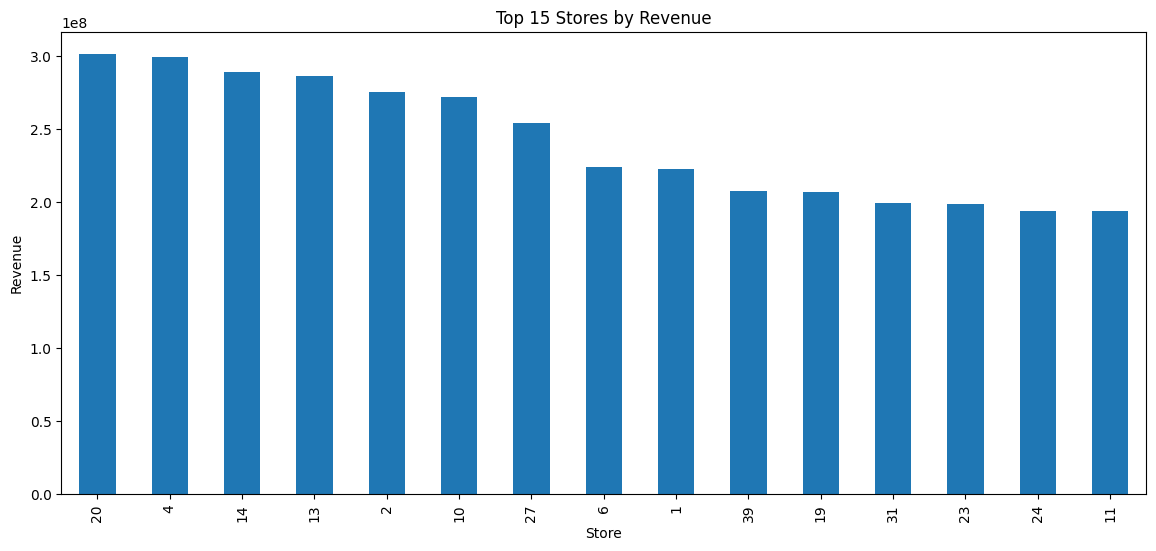

In [23]:
top_stores = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

top_stores.head(15).plot(kind="bar")

plt.title("Top 15 Stores by Revenue")
plt.ylabel("Revenue")

plt.show()

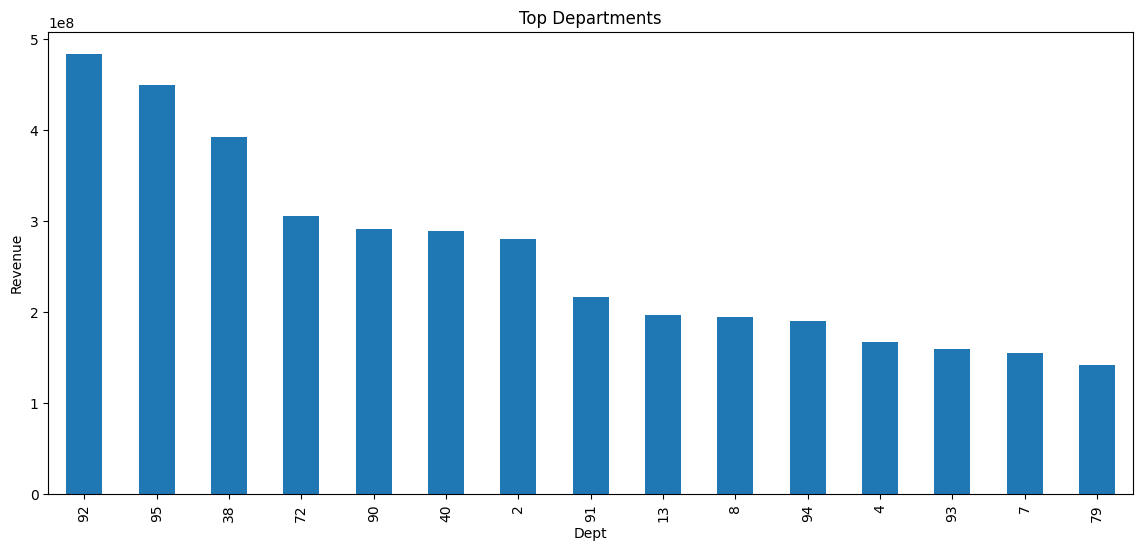

In [24]:
top_depts = (
    df.groupby("Dept")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

top_depts.head(15).plot(kind="bar")

plt.title("Top Departments")
plt.ylabel("Revenue")

plt.show()

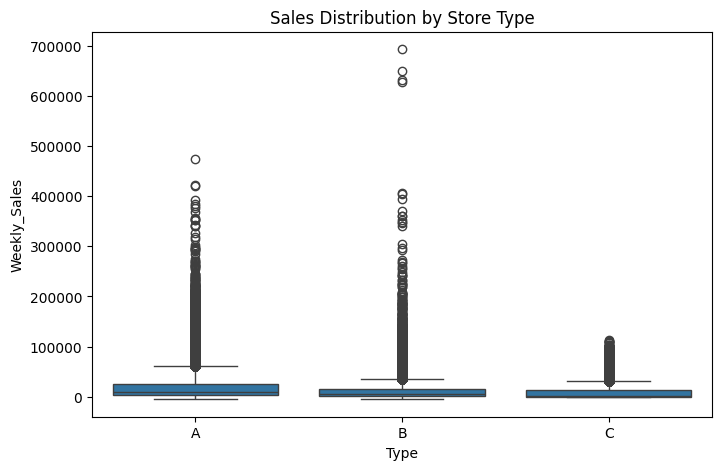

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Type",
    y="Weekly_Sales"
)

plt.title("Sales Distribution by Store Type")

plt.show()

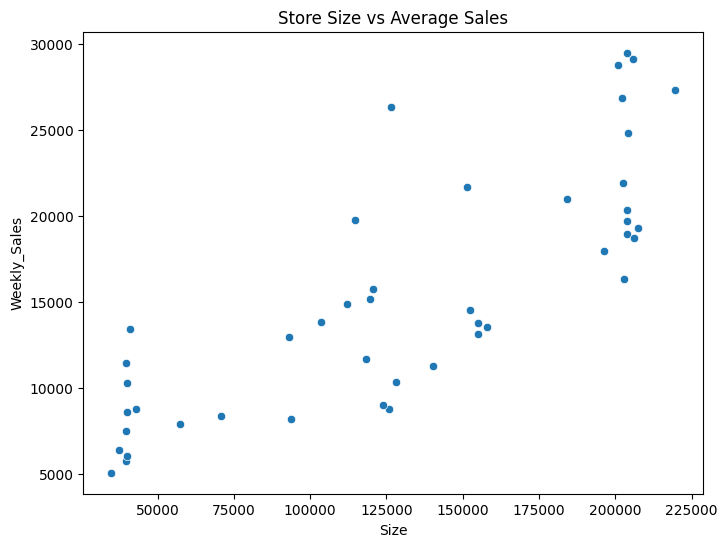

In [26]:
store_analysis = (
    df.groupby(["Store","Size"])
      ["Weekly_Sales"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=store_analysis,
    x="Size",
    y="Weekly_Sales"
)

plt.title("Store Size vs Average Sales")

plt.show()

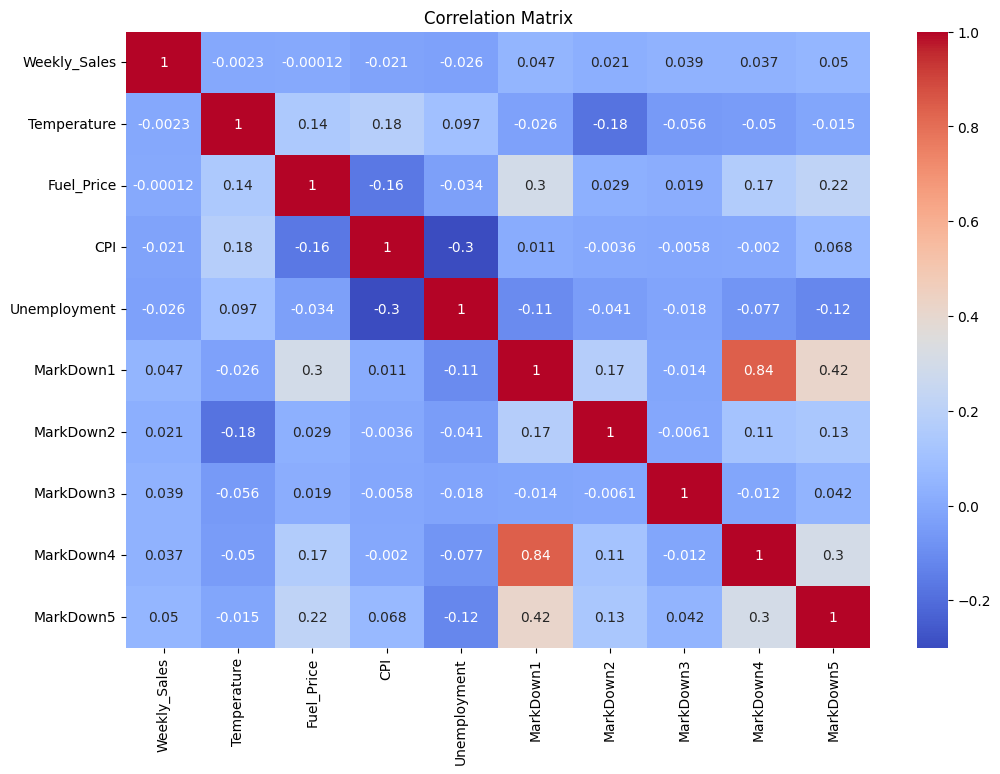

In [27]:
corr_cols = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

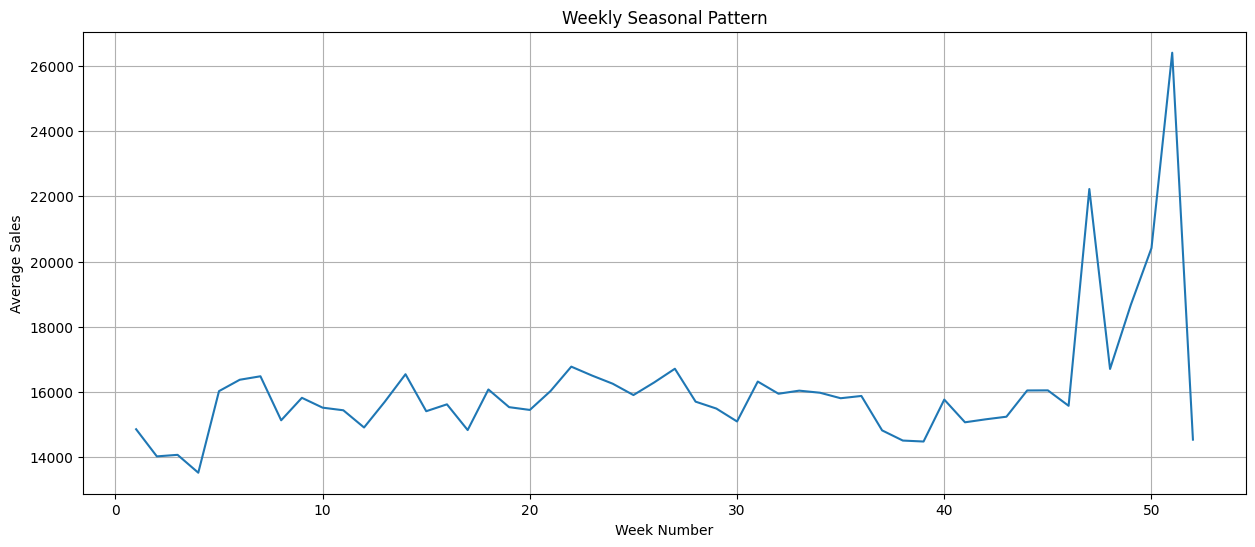

In [28]:
df["Week"] = (
    df["Date"]
      .dt
      .isocalendar()
      .week
      .astype(int)
)

weekly_pattern = (
    df.groupby("Week")
      ["Weekly_Sales"]
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    weekly_pattern.index,
    weekly_pattern.values
)

plt.title("Weekly Seasonal Pattern")
plt.xlabel("Week Number")
plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

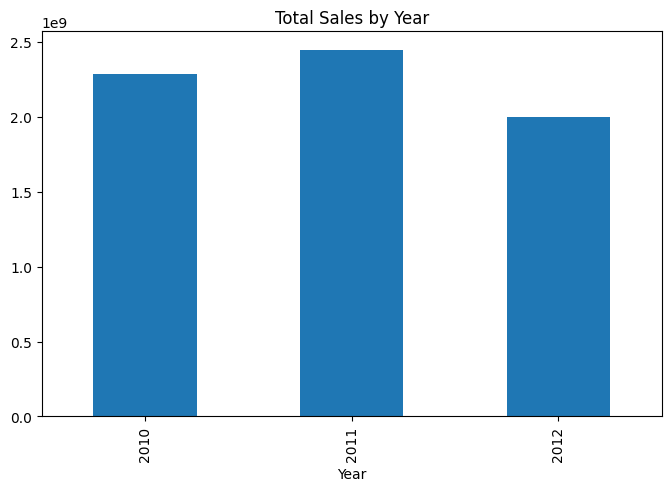

In [29]:
df["Year"] = df["Date"].dt.year

yearly_sales = (
    df.groupby("Year")
      ["Weekly_Sales"]
      .sum()
)

yearly_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Sales by Year")

plt.show()